# Stage 1 Pipeline Storyboard

This notebook walks through the artifacts created by Stage 1 and visualizes how each component of the labeling pipeline behaves on the collected data.

We will:
- load the processed OHLCV time series saved by Stage 1 and reproduce the quality checks,
- compute forward returns for the configured horizons and inspect their distribution,
- rebuild the alpha/beta thresholds to show how the calibration works,
- assign labels and study how BUY/HOLD/SELL segments appear on the price series,
- summarise the generated datasets and reports so other teammates can explore the outputs.

In [35]:
from __future__ import annotations

import json
import sys
from dataclasses import asdict
from pathlib import Path
from typing import Dict, List

import numpy as np
import pandas as pd

try:
    import yaml
except ImportError as exc:
    raise RuntimeError('PyYAML is required to run this notebook.') from exc

try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    sns.set_theme(style='whitegrid')
    HAS_PLOTS = True
except ImportError:
    HAS_PLOTS = False
    plt = None
    sns = None
    print('Install matplotlib and seaborn to enable visualizations.')

pd.options.display.max_rows = 120
pd.options.display.width = 120


In [36]:
PROJECT_ROOT = Path.cwd().parents[0]
DATA_ROOT = PROJECT_ROOT / 'data'
CONFIG_PATH = PROJECT_ROOT / 'configs' / 'labeling_paper.yaml'

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from stage1.pipeline_stage1 import (
    Stage1Paths,
    Stage1Config,
    DataQualityChecker,
    ForwardReturnCalculator,
    ThresholdCalibrator,
    LabelAssigner,
    interval_to_minutes,
)

with CONFIG_PATH.open('r', encoding='utf-8') as handle:
    raw_cfg: Dict[str, List[int]] = yaml.safe_load(handle)

percentiles_by_forW = raw_cfg.get('percentiles_by_forW', {})

paths = Stage1Paths(
    processed_dir=DATA_ROOT / 'processed',
    datasets_dir=DATA_ROOT / 'datasets',
    reports_dir=DATA_ROOT / 'reports',
)

cfg = Stage1Config(
    symbol=raw_cfg['symbol'],
    interval=raw_cfg['interval'],
    fee=float(raw_cfg['fee']),
    backW_values=[int(x) for x in raw_cfg['backW']],
    forW_values=[int(x) for x in raw_cfg['forW']],
    percentiles_by_forW={int(k): v for k, v in percentiles_by_forW.items()},
    paths=paths,
    calibration_mode=raw_cfg.get('calibration_mode', 'exact_paper'),
    alpha_const=raw_cfg.get('alpha_const'),
    beta_const=raw_cfg.get('beta_const'),
    single_candle_percentiles=raw_cfg.get('single_candle_percentiles'),
    scale_beta_per_step=raw_cfg.get('scale_beta_per_step', 0.10),
    start_date=raw_cfg.get('start_date', '1 Jan 2020'),
)

cfg


Stage1Config(symbol='BTCUSDT', interval='4h', fee=0.002, backW_values=[1, 2, 3, 4, 5], forW_values=[1, 2, 3, 4, 5], percentiles_by_forW={}, paths=Stage1Paths(processed_dir=PosixPath('/home/kamil/binance-bot/data/processed'), datasets_dir=PosixPath('/home/kamil/binance-bot/data/datasets'), reports_dir=PosixPath('/home/kamil/binance-bot/data/reports')), calibration_mode='exact_paper', alpha_const=None, beta_const=None, single_candle_percentiles={'alpha_pct': 0.24, 'beta_pct': 0.997}, scale_beta_per_step=0.1, start_date='1 Jan 2020')

## Stage 1 — load and audit the OHLCV history

Stage 1 begins by pulling raw candles from Binance and writing the cleaned OHLCV series to `data/processed`. We reproduce that step here and run the quality checks that gate the rest of the pipeline.

In [37]:
processed_file = paths.processed_file(cfg.symbol, cfg.interval)
if not processed_file.exists():
    raise FileNotFoundError(f'Processed file not found: {processed_file}')

price_df = pd.read_parquet(processed_file)
if not isinstance(price_df.index, pd.DatetimeIndex):
    idx_col = 'open_time' if 'open_time' in price_df.columns else price_df.columns[0]
    price_df[idx_col] = pd.to_datetime(price_df[idx_col], utc=True)
    price_df = price_df.set_index(idx_col)
price_df = price_df.sort_index()
price_df.index = pd.to_datetime(price_df.index, utc=True)
price_df.head()


,open,high,low,close,volume
ts,,,,,
2020-01-01 00:00:00+00:00,7195.24,7245.00,7175.46,7225.01,2833.749180
2020-01-01 04:00:00+00:00,7225.00,7236.27,7199.11,7209.83,2061.295051
2020-01-01 08:00:00+00:00,7209.83,7237.73,7180.00,7197.20,3166.654361
2020-01-01 12:00:00+00:00,7197.20,7255.00,7196.15,7234.19,3492.537459
2020-01-01 16:00:00+00:00,7234.20,7249.99,7214.00,7229.48,2980.583291


In [38]:
checker = DataQualityChecker()
interval_minutes = interval_to_minutes(cfg.interval)
qa_report = checker.evaluate(price_df, interval_minutes)
pd.DataFrame([asdict(qa_report)])


,gaps_pct,n_dupes,n_nan,status,notes
0,0.007911,0,0,OK,First gap starts at 2020-02-19T16:00:00+00:00


In [39]:
freq = pd.Timedelta(minutes=interval_minutes)
expected_index = pd.date_range(price_df.index[0], price_df.index[-1], freq=freq, tz=price_df.index.tz)
missing_slots = expected_index.difference(price_df.index)
duplicate_slots = price_df.index[price_df.index.duplicated()]
print(f'Total expected slots: {len(expected_index):,}')
print(f'Observed candles:    {len(price_df):,}')
print(f'Missing slots:       {len(missing_slots):,}')
print(f'Duplicated slots:    {len(duplicate_slots):,}')

def summarise_missing(idx):
    segments = []
    if idx.empty:
        return segments
    start = idx[0]
    prev = idx[0]
    for ts in idx[1:]:
        if ts - prev > freq:
            segments.append((start, prev))
            start = ts
        prev = ts
    segments.append((start, prev))
    return segments

gap_segments = summarise_missing(missing_slots)
if gap_segments:
    preview = pd.DataFrame(gap_segments, columns=['gap_start', 'gap_end']).head()
    display(preview)
else:
    print('No gaps detected by the helper summariser.')


Total expected slots: 12,640
Observed candles:    12,639
Missing slots:       1
Duplicated slots:    0


,gap_start,gap_end
0,2020-02-19 12:00:00+00:00,2020-02-19 12:00:00+00:00


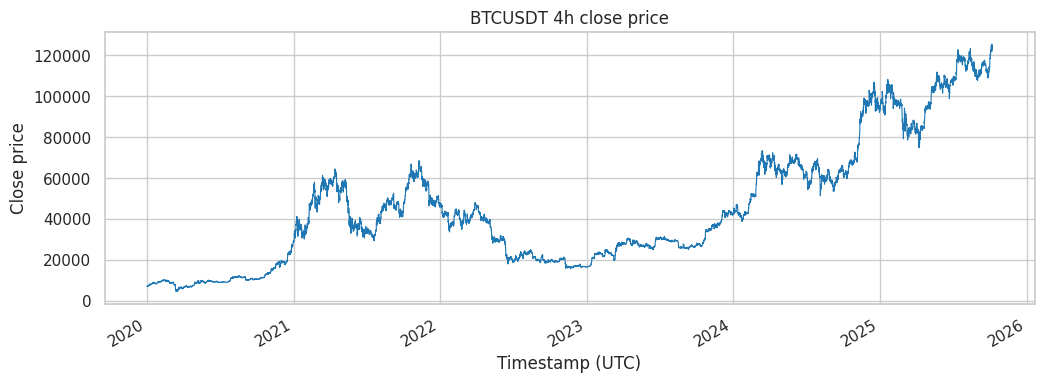

In [40]:
if HAS_PLOTS:
    fig, ax = plt.subplots(figsize=(12, 4))
    price_df['close'].plot(ax=ax, lw=0.8, color='tab:blue')
    ax.set_title(f'{cfg.symbol} {cfg.interval} close price')
    ax.set_ylabel('Close price')
    ax.set_xlabel('Timestamp (UTC)')
    plt.show()
else:
    print('Plotting libraries not installed.')


## Stage 2 — forward return computation

With a clean OHLCV series we recreate the forward returns that feed the labeling rules.

In [41]:
return_calc = ForwardReturnCalculator(cfg.fee)
forward_returns_full: Dict[int, pd.Series] = {}
forward_summaries = []

for forW in cfg.forW_values:
    series = return_calc.compute(price_df, forW)
    forward_returns_full[forW] = series
    valid = series.dropna()
    if valid.empty:
        continue
    forward_summaries.append({
        'forW': forW,
        'count': int(valid.count()),
        'mean': float(valid.mean()),
        'std': float(valid.std()),
        'min': float(valid.min()),
        'p05': float(valid.quantile(0.05)),
        'median': float(valid.quantile(0.5)),
        'p95': float(valid.quantile(0.95)),
        'max': float(valid.max()),
    })

forward_summary_df = pd.DataFrame(forward_summaries)
forward_summary_df


,forW,count,mean,std,min,p05,median,p95,max
0,1,12638,-0.003384,0.018211,-0.220803,-0.031179,-0.003613,0.024806,0.146414
1,2,12637,-0.003077,0.022251,-0.238900,-0.036564,-0.003483,0.031713,0.171985
2,3,12636,-0.002761,0.025941,-0.353959,-0.041930,-0.003323,0.038234,0.177672
3,4,12635,-0.002446,0.029188,-0.376794,-0.046352,-0.003187,0.044188,0.213615
4,5,12634,-0.002132,0.032034,-0.398263,-0.050672,-0.002975,0.048876,0.219503


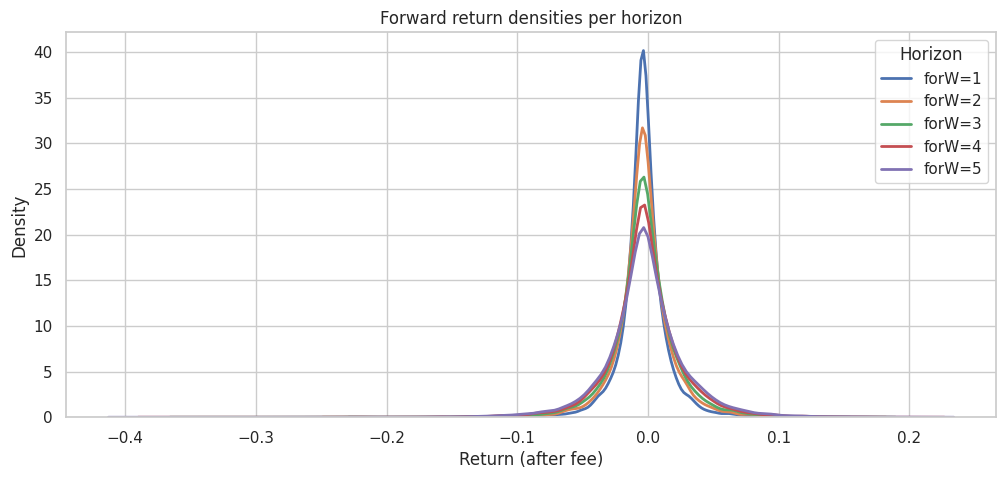

In [42]:
if HAS_PLOTS and forward_returns_full:
    fig, ax = plt.subplots(figsize=(12, 5))
    for forW, series in forward_returns_full.items():
        valid = series.dropna()
        if valid.empty:
            continue
        sns.kdeplot(valid, ax=ax, label=f'forW={forW}', linewidth=2)
    ax.set_title('Forward return densities per horizon')
    ax.set_xlabel('Return (after fee)')
    ax.legend(title='Horizon')
    plt.show()
else:
    print('No forward returns to visualise.')


## Stage 3 — threshold calibration

Stage 1 reuses the paper's calibration scheme: compute global alpha/beta from single-bar returns and scale beta per forward horizon.

In [43]:
calibrator = ThresholdCalibrator(cfg)
calibrator.prepare_global_thresholds(price_df)

threshold_records = []
for forW in cfg.forW_values:
    forward_abs = forward_returns_full.get(forW, pd.Series(dtype='float64')).abs().dropna()
    alpha, beta = calibrator.calibrate(forward_abs, forW)
    threshold_records.append({'forW': forW, 'alpha': float(alpha), 'beta': float(beta)})

threshold_df = pd.DataFrame(threshold_records)
threshold_df


,forW,alpha,beta
0,1,0.003523,0.084313
1,2,0.003523,0.092744
2,3,0.003523,0.101175
3,4,0.003523,0.109606
4,5,0.003523,0.118038


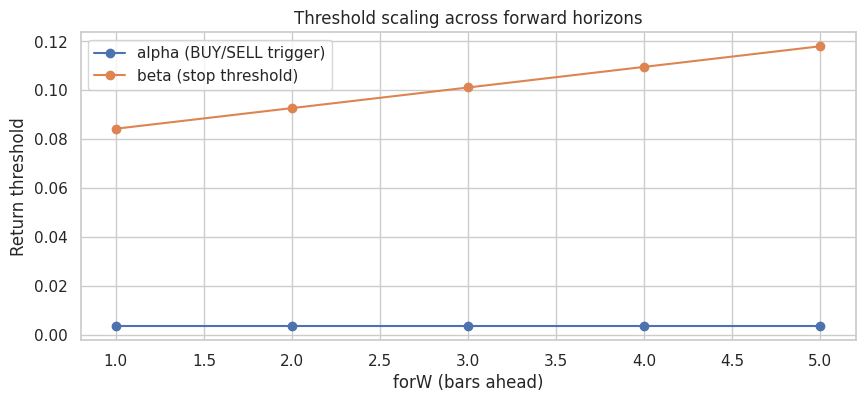

In [44]:
if HAS_PLOTS and not threshold_df.empty:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(threshold_df['forW'], threshold_df['alpha'], marker='o', label='alpha (BUY/SELL trigger)')
    ax.plot(threshold_df['forW'], threshold_df['beta'], marker='o', label='beta (stop threshold)')
    ax.set_title('Threshold scaling across forward horizons')
    ax.set_xlabel('forW (bars ahead)')
    ax.set_ylabel('Return threshold')
    ax.legend()
    plt.show()
else:
    print('Threshold table is empty.')


## Stage 4 — label assignment

With forward returns and thresholds in hand we can reconstruct BUY/HOLD/SELL labels and examine their distribution.

In [45]:
assigner = LabelAssigner()
labels_by_forw: Dict[int, pd.Series] = {}
distribution_rows = []

for _, row in threshold_df.iterrows():
    forW = int(row['forW'])
    alpha = float(row['alpha'])
    beta = float(row['beta'])
    forward_series = forward_returns_full[forW]
    labels = assigner.assign(forward_series, alpha, beta)
    labels_by_forw[forW] = labels
    nan_count = int(labels.isna().sum())
    valid_total = int(labels.count())
    counts = {label: int((labels == label).sum()) for label in ['BUY', 'HOLD', 'SELL']}
    distribution_rows.append({
        'forW': forW,
        'valid': valid_total,
        'nan': nan_count,
        'count_BUY': counts['BUY'],
        'count_HOLD': counts['HOLD'],
        'count_SELL': counts['SELL'],
        'share_BUY': counts['BUY'] / valid_total if valid_total else np.nan,
        'share_HOLD': counts['HOLD'] / valid_total if valid_total else np.nan,
        'share_SELL': counts['SELL'] / valid_total if valid_total else np.nan,
    })

label_distribution_df = pd.DataFrame(distribution_rows).sort_values('forW').reset_index(drop=True)
label_distribution_df


,forW,valid,nan,count_BUY,count_HOLD,count_SELL,share_BUY,share_HOLD,share_SELL
0,1,12638,1,3229,3071,6338,0.255499,0.242997,0.501503
1,2,12637,2,3741,2643,6253,0.296035,0.209148,0.494817
2,3,12636,3,4142,2303,6191,0.327794,0.182257,0.489949
3,4,12635,4,4378,2125,6132,0.346498,0.168184,0.485319
4,5,12634,5,4600,1957,6077,0.364097,0.154899,0.481004


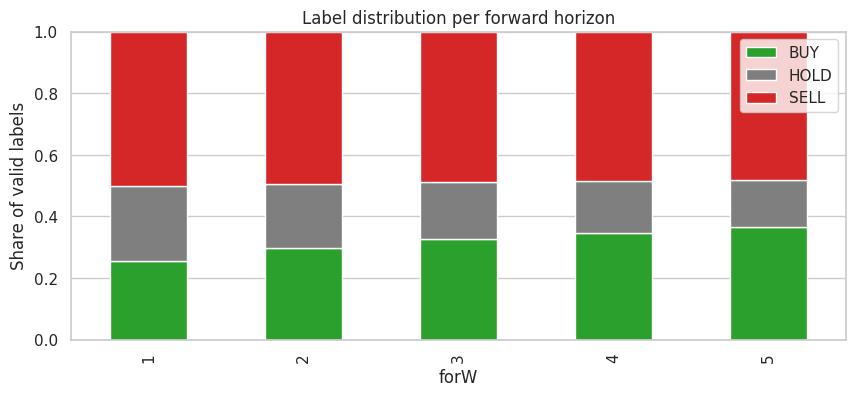

In [52]:
if HAS_PLOTS and not label_distribution_df.empty:
    plot_df = label_distribution_df.set_index('forW')[['share_BUY', 'share_HOLD', 'share_SELL']]
    fig, ax = plt.subplots(figsize=(10, 4))
    plot_df.plot(kind='bar', stacked=True, color=['#2ca02c', '#7f7f7f', '#d62728'], ax=ax)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Share of valid labels')
    ax.set_title('Label distribution per forward horizon')
    ax.legend(['BUY', 'HOLD', 'SELL'], loc='upper right')
    plt.show()
else:
    print('No label distribution to chart.')


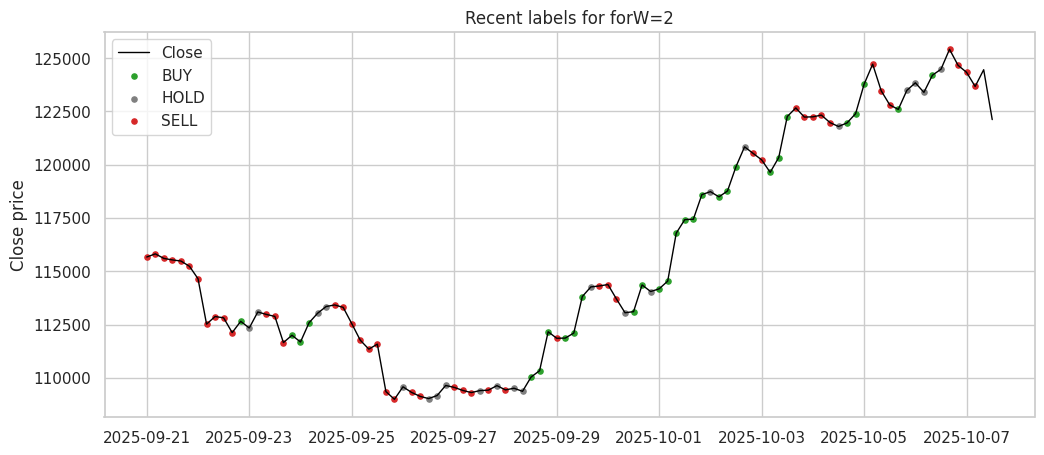

In [56]:
focus_forW = 2 if 3 in labels_by_forw else max(labels_by_forw) if labels_by_forw else None
if HAS_PLOTS and focus_forW is not None:
    labels_focus = labels_by_forw[focus_forW]
    window = min(100, len(price_df))
    tail_idx = price_df.index[-window:]
    tail_df = price_df.loc[tail_idx].copy()
    tail_df['label'] = labels_focus.loc[tail_idx]
    color_map = {'BUY': '#2ca02c', 'HOLD': '#7f7f7f', 'SELL': '#d62728'}
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(tail_df.index, tail_df['close'], color='black', linewidth=1.0, label='Close')
    for label, color in color_map.items():
        mask = tail_df['label'] == label
        if mask.any():
            ax.scatter(tail_df.index[mask], tail_df['close'][mask], s=14, label=label, color=color)
    ax.set_title(f'Recent labels for forW={focus_forW}')
    ax.set_ylabel('Close price')
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc='upper left')
    plt.show()
else:
    print('No labels available for the timeline plot.')


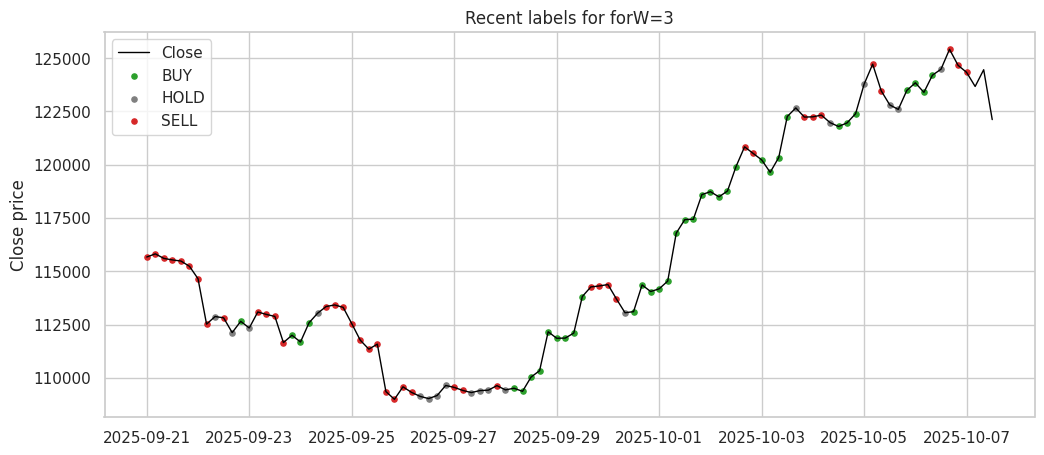

In [57]:
focus_forW = 3 if 3 in labels_by_forw else max(labels_by_forw) if labels_by_forw else None
if HAS_PLOTS and focus_forW is not None:
    labels_focus = labels_by_forw[focus_forW]
    window = min(100, len(price_df))
    tail_idx = price_df.index[-window:]
    tail_df = price_df.loc[tail_idx].copy()
    tail_df['label'] = labels_focus.loc[tail_idx]
    color_map = {'BUY': '#2ca02c', 'HOLD': '#7f7f7f', 'SELL': '#d62728'}
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(tail_df.index, tail_df['close'], color='black', linewidth=1.0, label='Close')
    for label, color in color_map.items():
        mask = tail_df['label'] == label
        if mask.any():
            ax.scatter(tail_df.index[mask], tail_df['close'][mask], s=14, label=label, color=color)
    ax.set_title(f'Recent labels for forW={focus_forW}')
    ax.set_ylabel('Close price')
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc='upper left')
    plt.show()
else:
    print('No labels available for the timeline plot.')


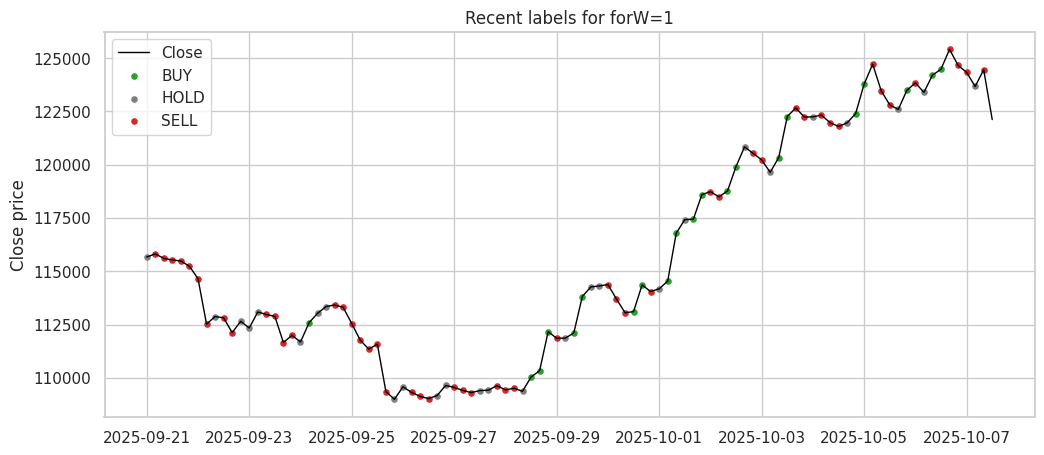

In [58]:
focus_forW = 1 if 3 in labels_by_forw else max(labels_by_forw) if labels_by_forw else None
if HAS_PLOTS and focus_forW is not None:
    labels_focus = labels_by_forw[focus_forW]
    window = min(100, len(price_df))
    tail_idx = price_df.index[-window:]
    tail_df = price_df.loc[tail_idx].copy()
    tail_df['label'] = labels_focus.loc[tail_idx]
    color_map = {'BUY': '#2ca02c', 'HOLD': '#7f7f7f', 'SELL': '#d62728'}
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(tail_df.index, tail_df['close'], color='black', linewidth=1.0, label='Close')
    for label, color in color_map.items():
        mask = tail_df['label'] == label
        if mask.any():
            ax.scatter(tail_df.index[mask], tail_df['close'][mask], s=14, label=label, color=color)
    ax.set_title(f'Recent labels for forW={focus_forW}')
    ax.set_ylabel('Close price')
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc='upper left')
    plt.show()
else:
    print('No labels available for the timeline plot.')


## Stage 5 — dataset and report artifacts

Stage 1 persists a JSON report and a Parquet dataset for every `(backW, forW)` pair. We load those artifacts to show the coverage that downstream teams can rely on.

In [59]:
report_paths = sorted(paths.reports_dir.glob('*.json'))
print(f'Found {len(report_paths)} reports in {paths.reports_dir}')

def load_reports(paths_list: List[Path]) -> pd.DataFrame:
    records = []
    for path in paths_list:
        with path.open('r', encoding='utf-8') as handle:
            payload = json.load(handle)
        record = {
            'symbol': payload['symbol'],
            'interval': payload['interval'],
            'backW': int(payload['backW']),
            'forW': int(payload['forW']),
            'alpha': float(payload['alpha']),
            'beta': float(payload['beta']),
            'fee': float(payload['fee']),
            'dataset_path': payload['dataset_path'],
            'n_valid': int(payload['n_valid']),
            'n_total': int(payload['n_total']),
            'count_BUY': int(payload['counts'].get('BUY', 0)),
            'count_HOLD': int(payload['counts'].get('HOLD', 0)),
            'count_SELL': int(payload['counts'].get('SELL', 0)),
            'count_NaN': int(payload['counts'].get('NaN', 0)),
        }
        distribution = payload.get('distribution', {})
        record['share_BUY'] = float(distribution.get('BUY', np.nan))
        record['share_HOLD'] = float(distribution.get('HOLD', np.nan))
        record['share_SELL'] = float(distribution.get('SELL', np.nan))
        records.append(record)
    if not records:
        return pd.DataFrame()
    df = pd.DataFrame(records).sort_values(['forW', 'backW']).reset_index(drop=True)
    return df

report_df = load_reports(report_paths)
report_df.head()


Found 50 reports in /home/kamil/binance-bot/data/reports


,symbol,interval,backW,forW,alpha,beta,fee,dataset_path,n_valid,n_total,count_BUY,count_HOLD,count_SELL,count_NaN,share_BUY,share_HOLD,share_SELL
0,BTCUSDC,4h,1,1,0.000151,0.112643,0.002,data/datasets/BTCUSDC_4h_backW1_forW1.parquet,11654,11654,4124,129,7401,0,0.353870,0.011069,0.635061
1,BTCUSDT,4h,1,1,0.003523,0.084313,0.002,data/datasets/BTCUSDT_4h_backW1_forW1.parquet,12638,12638,3229,3071,6338,0,0.255499,0.242997,0.501503
2,BTCUSDC,4h,2,1,0.000151,0.112643,0.002,data/datasets/BTCUSDC_4h_backW2_forW1.parquet,11653,11653,4124,129,7400,0,0.353900,0.011070,0.635030
3,BTCUSDT,4h,2,1,0.003523,0.084313,0.002,data/datasets/BTCUSDT_4h_backW2_forW1.parquet,12637,12637,3229,3070,6338,0,0.255520,0.242937,0.501543
4,BTCUSDC,4h,3,1,0.000151,0.112643,0.002,data/datasets/BTCUSDC_4h_backW3_forW1.parquet,11652,11652,4124,129,7399,0,0.353931,0.011071,0.634998


In [60]:
sample_backW = max(cfg.backW_values)
sample_forW = max(cfg.forW_values)
sample_path = paths.dataset_file(cfg.symbol, cfg.interval, sample_backW, sample_forW)
print(f'Sample dataset path: {sample_path}')
if sample_path.exists():
    sample_df = pd.read_parquet(sample_path)
    display(sample_df.head())
else:
    print('Sample dataset not found. Run Stage 1 to regenerate datasets.')


Sample dataset path: /home/kamil/binance-bot/data/datasets/BTCUSDT_4h_backW5_forW5.parquet


,ts,label,backW,forW,alpha,beta,fee,ema_backW
0,2020-01-01 16:00:00+00:00,SELL,5,5,0.003523,0.118038,0.002,7222.920741
1,2020-01-01 20:00:00+00:00,SELL,5,5,0.003523,0.118038,0.002,7215.563827
2,2020-01-02 00:00:00+00:00,SELL,5,5,0.003523,0.118038,0.002,7186.912551
3,2020-01-02 04:00:00+00:00,SELL,5,5,0.003523,0.118038,0.002,7161.465034
4,2020-01-02 08:00:00+00:00,BUY,5,5,0.003523,0.118038,0.002,7154.240023


## Takeaways

- The QA report confirms the processed OHLCV feed is free of glaring gaps, which keeps the downstream calculations reliable.
- Forward return densities widen with the forecasting horizon, and beta scales accordingly while alpha remains anchored by single-bar statistics.
- Label distributions stay balanced enough for supervised learning, and the heatmaps expose how back/forward window choices affect BUY versus SELL coverage.
- The Stage 1 reports and datasets in `data/` provide a ready-to-use catalog of artifacts for experimentation and Stage 2 feature generation.

In [2]:
# Jupyter cell — quick α/β visualization on your processed data
import pandas as pd, numpy as np, matplotlib.pyplot as plt

path = "../data/processed/BTCUSDT_4h.parquet"   # podmień ścieżkę
df = pd.read_parquet(path).sort_index()

# 1-bar returns and percentiles
r1 = (df["close"] - df["open"]) / df["open"]
alpha_pct, beta_pct = 0.25, 0.997
alpha = abs(r1.quantile(alpha_pct))
beta  = abs(r1.quantile(beta_pct))

# scale beta for chosen forW
forW = 1
beta_forw = beta * (1 + 0.10*(forW-1))

# forward returns for labeling
fwd = (df["close"].shift(-forW) - df["open"]) / df["open"] - 0.002
labels = np.where((fwd.abs() <= alpha) | (fwd.abs() >= beta_forw), "HOLD",
          np.where((fwd > alpha) & (fwd < beta_forw), "BUY",
          np.where((fwd < -alpha) & (fwd > -beta_forw), "SELL", np.nan)))

# histogram |R| with α and β_forW
plt.figure()
plt.hist(fwd.dropna().abs(), bins=100)
plt.axvline(alpha); plt.axvline(beta_forw)
plt.title("Abs forward returns with α and β_forW")
plt.xlabel("|R|"); plt.ylabel("Count")
plt.show()

DTypePromotionError: The DType <class 'numpy.dtypes.StrDType'> could not be promoted by <class 'numpy.dtypes._PyFloatDType'>. This means that no common DType exists for the given inputs. For example they cannot be stored in a single array unless the dtype is `object`. The full list of DTypes is: (<class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes._PyFloatDType'>)